# 02 - Popularity Prediction -
**Spotify Data Mining | CISC 4631 | Group 3**

### Research Questions
1. Can audio features predict whether a song will be **globally popular**?
2. Can audio features predict whether a song will be popular **within its genre**?
3. Do the same features drive both, or does genre context change what matters?
4. Does the task get easier if we collapse popularity to a **binary** target?

### Outline
1. Load shared data
2. Preprocess, split (60/20/20), feature selection, class-balance check
3. Baseline classifiers: KNN, Decision Tree, Naive Bayes
4. XGBoost (gradient-boosted trees)
5. Binary classification (two thresholds: Popular ≥ 46, and Popular ≥ training-set median)
6. Compare all models
7. Summary

> **Prerequisite:** Run `00_data_setup.ipynb` first to generate `data/df_popularity_stratified.csv`.

## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

import warnings
warnings.filterwarnings('ignore')

# GLOBAL CONSTANTS
SEED            = 42
DRIVE_DATA_PATH = '/content/drive/MyDrive/data-mining-spotify-team3/cleanedData'
AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'duration_ms'
]
KEY_FEATURES = ['key', 'mode']
ALL_FEATURES = AUDIO_FEATURES + KEY_FEATURES
LABEL_MAP = {'Low': 0, 'Mid': 1, 'High': 2}

np.random.seed(SEED)

## 1. Load Data

In [3]:
import os
df = pd.read_csv(os.path.join(DRIVE_DATA_PATH, 'df_popularity_stratified.csv'))
print(f'Loaded: {df.shape}')
print('\nGlobal popularity class:')
print(df['popularity_class'].value_counts())
print('\nGenre-relative popularity class:')
print(df['genre_popularity_class'].value_counts())
df.head()

Loaded: (10500, 17)

Global popularity class:
popularity_class
High    3500
Low     3500
Mid     3500
Name: count, dtype: int64

Genre-relative popularity class:
genre_popularity_class
High    5348
Mid     2601
Low     2551
Name: count, dtype: int64


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,key,mode,genre,year,popularity,popularity_class,genre_popularity_class
0,0.642,0.469,-7.354,0.0303,0.374,0.000000,0.0816,0.286,125.939,209632,10,1,Classical,2019,48,High,High
1,0.423,0.179,-14.852,0.0413,0.916,0.000016,0.1200,0.179,78.738,199920,0,0,Classical,2005,50,High,High
2,0.285,0.150,-12.306,0.0320,0.792,0.200000,0.1020,0.138,83.768,224306,0,0,Classical,2019,58,High,High
3,0.718,0.484,-10.376,0.5230,0.312,0.000000,0.1270,0.692,113.855,142044,11,1,Classical,2015,67,High,High
4,0.425,0.701,-7.937,0.2790,0.312,0.000000,0.1490,0.532,75.167,206933,6,0,Classical,2005,53,High,High


## 2. Preprocess & Split

- Scale audio features (StandardScaler).
- Encode labels.
- 60/20/20 train/eval/test split — eval for model selection, test held out for final report.
- Class distribution check (decides whether SMOTE is needed).
- Feature selection via mutual information on the training set.

In [4]:
# Scale features with StandardScaler. Preserve df's original index so we can recover
# raw `popularity` scores for the binary section later (Section 5).
scaler = StandardScaler()
X = pd.DataFrame(
    scaler.fit_transform(df[ALL_FEATURES]),
    columns=ALL_FEATURES,
    index=df.index
)

# Encode labels
y_global = df['popularity_class'].map(LABEL_MAP)
y_genre  = df['genre_popularity_class'].map(LABEL_MAP)

print('Feature matrix shape:', X.shape)
print('Global label distribution:', y_global.value_counts().to_dict())
print('Genre-relative label distribution:', y_genre.value_counts().to_dict())

Feature matrix shape: (10500, 12)
Global label distribution: {2: 3500, 0: 3500, 1: 3500}
Genre-relative label distribution: {2: 5348, 1: 2601, 0: 2551}


In [5]:
# 60/20/20 split, stratified on the global popularity label
X_trainval, X_test, y_trainval_g, y_test_g, y_trainval_gr, y_test_gr = train_test_split(
    X, y_global, y_genre,
    test_size=0.20, random_state=SEED, stratify=y_global
)
X_train, X_eval, y_train_g, y_eval_g, y_train_gr, y_eval_gr = train_test_split(
    X_trainval, y_trainval_g, y_trainval_gr,
    test_size=0.25, random_state=SEED, stratify=y_trainval_g
)

print(f'Train: {len(X_train):,} ({len(X_train) / len(X):.0%})')
print(f'Eval:  {len(X_eval):,} ({len(X_eval) / len(X):.0%})')
print(f'Test:  {len(X_test):,} ({len(X_test) / len(X):.0%})')

Train: 6,300 (60%)
Eval:  2,100 (20%)
Test:  2,100 (20%)


### 2.1 Feature Selection

Rank the 12 features by mutual information against the global popularity label. Since both
targets use the same input features, we use a single selection based on the primary target.
Scoring is fit on train only (no leakage from eval/test).

Mutual information ranking (target = global popularity):
         Feature  MI Score
        loudness  0.020777
instrumentalness  0.011159
         valence  0.008467
    acousticness  0.006720
        liveness  0.006358
    danceability  0.005485
            mode  0.004540
             key  0.002988
     speechiness  0.002764
          energy  0.000000
     duration_ms  0.000000
           tempo  0.000000


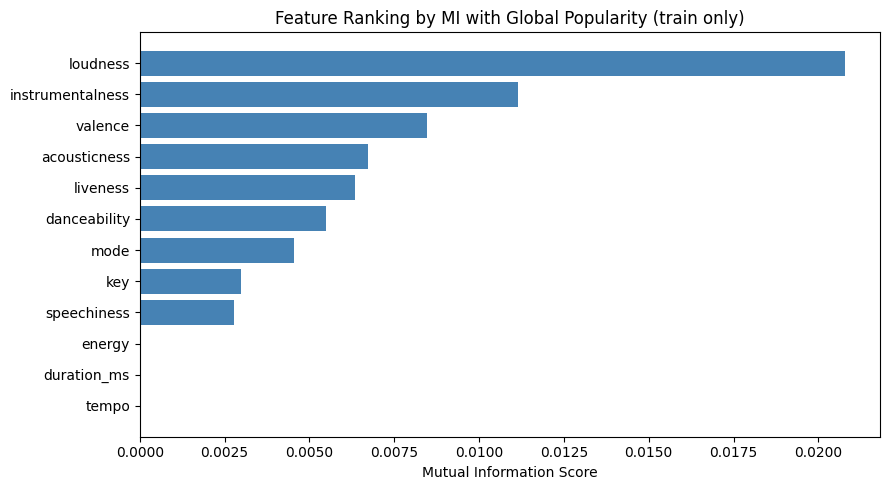


Selected top-10 features: ['loudness', 'instrumentalness', 'valence', 'acousticness', 'liveness', 'danceability', 'mode', 'key', 'speechiness', 'energy']
Dropped: ['tempo', 'duration_ms']


In [6]:
mi_scorer = SelectKBest(score_func=mutual_info_classif, k='all')
mi_scorer.fit(X_train, y_train_g)

mi_scores = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'MI Score': mi_scorer.scores_
}).sort_values('MI Score', ascending=False).reset_index(drop=True)

print('Mutual information ranking (target = global popularity):')
print(mi_scores.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mi_scores['Feature'][::-1], mi_scores['MI Score'][::-1], color='steelblue')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Ranking by MI with Global Popularity (train only)')
plt.tight_layout()
plt.show()

# Tune K here
K = 10
SELECTED_FEATURES = mi_scores['Feature'].head(K).tolist()
print(f'\nSelected top-{K} features: {SELECTED_FEATURES}')
print(f'Dropped: {[f for f in ALL_FEATURES if f not in SELECTED_FEATURES]}')

# Project all splits onto the selected feature subset
X_train_sel = X_train[SELECTED_FEATURES]
X_eval_sel  = X_eval[SELECTED_FEATURES]
X_test_sel  = X_test[SELECTED_FEATURES]

### 2.2 Class Distribution Check

Nb 00 builds the dataset via stratified sampling (500 per class × genre), so we expect both
targets to be roughly balanced. We verify — if the imbalance ratio (max/min class count)
exceeds 1.5, we apply SMOTE on the training set to rebalance. Otherwise SMOTE is skipped.

In [7]:
def check_balance(y, label):
    counts = Counter(y)
    ratio = max(counts.values()) / min(counts.values())
    print(f'{label}: {dict(counts)} | imbalance ratio = {ratio:.2f}')
    return ratio

print('Train set class balance:')
r_g  = check_balance(y_train_g,  'Global popularity        ')
r_gr = check_balance(y_train_gr, 'Genre-relative popularity')

IMBALANCE_THRESHOLD = 1.5

if r_g > IMBALANCE_THRESHOLD or r_gr > IMBALANCE_THRESHOLD:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=SEED)
    print(f'\nImbalance detected (threshold={IMBALANCE_THRESHOLD}). Applying SMOTE to training set.')
    if r_g > IMBALANCE_THRESHOLD:
        X_train_g_sel, y_train_g = smote.fit_resample(X_train_sel, y_train_g)
        print(f'  Global target rebalanced: {dict(Counter(y_train_g))}')
    else:
        X_train_g_sel = X_train_sel
    if r_gr > IMBALANCE_THRESHOLD:
        X_train_gr_sel, y_train_gr = smote.fit_resample(X_train_sel, y_train_gr)
        print(f'  Genre-relative target rebalanced: {dict(Counter(y_train_gr))}')
    else:
        X_train_gr_sel = X_train_sel
else:
    print(f'\nBoth targets within {IMBALANCE_THRESHOLD}x imbalance threshold — SMOTE not applied.')
    X_train_g_sel  = X_train_sel
    X_train_gr_sel = X_train_sel

Train set class balance:
Global popularity        : {1: 2100, 0: 2100, 2: 2100} | imbalance ratio = 1.00
Genre-relative popularity: {1: 1524, 2: 3224, 0: 1552} | imbalance ratio = 2.12

Imbalance detected (threshold=1.5). Applying SMOTE to training set.
  Genre-relative target rebalanced: {1: 3224, 2: 3224, 0: 3224}


## 3. Baseline Classifiers
KNN, Decision Tree, and Naive Bayes — tested on both popularity targets.

In [8]:
def evaluate(name, model, X_tr, y_tr, X_ev, y_ev, X_te, y_te, target_names=None):
    """
    Fit on train, run 10-fold CV on train, evaluate on eval set, score test set.
    Returns (fitted_model, test_predictions). Eval-set accuracy is printed for tuning;
    test is in Section 6 for reporting.

    target_names: list of class labels for the classification report. Defaults to
    the 3-class popularity labels; pass ['Not-Popular', 'Popular'] for binary.
    """
    if target_names is None:
        target_names = ['Low', 'Mid', 'High']

    model.fit(X_tr, y_tr)

    # 10-fold CV on train (stability estimate)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=10, scoring='accuracy')
    print(f'\n=== {name} ===')
    print("CV Accuracy (train, 10-fold): %0.2f (+/- %0.2f)" % (cv_scores.mean(), cv_scores.std() * 2))

    # Eval-set check
    eval_preds = model.predict(X_ev)
    print(f'Eval Accuracy: {accuracy_score(y_ev, eval_preds):.4f}')

    # Test-set final predictions (reported once in Section 6)
    test_preds = model.predict(X_te)
    print('\n--- TEST SET ---')
    print(classification_report(y_te, test_preds, target_names=target_names))
    disp = ConfusionMatrixDisplay(
        confusion_matrix(y_te, test_preds),
        display_labels=target_names
    )
    disp.plot(cmap='Blues')
    plt.title(f'{name} — Test Set')
    plt.show()
    return model, test_preds

### 3.1 Target: Global Popularity

TARGET: GLOBAL POPULARITY

=== KNN (k=5) — Global ===
CV Accuracy (train, 10-fold): 0.36 (+/- 0.03)
Eval Accuracy: 0.3610

--- TEST SET ---
              precision    recall  f1-score   support

         Low       0.35      0.45      0.39       700
         Mid       0.33      0.32      0.33       700
        High       0.38      0.28      0.32       700

    accuracy                           0.35      2100
   macro avg       0.35      0.35      0.35      2100
weighted avg       0.35      0.35      0.35      2100



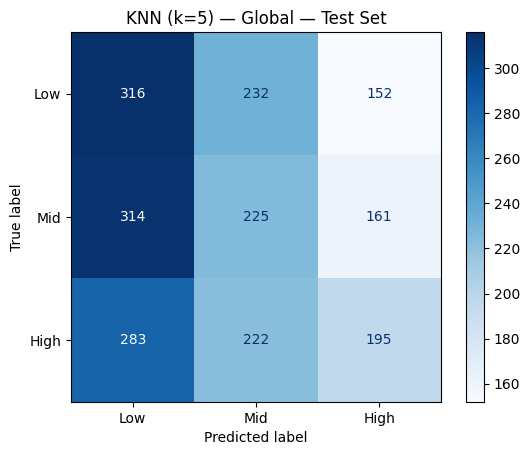


=== Decision Tree — Global ===
CV Accuracy (train, 10-fold): 0.38 (+/- 0.03)
Eval Accuracy: 0.3938

--- TEST SET ---
              precision    recall  f1-score   support

         Low       0.36      0.35      0.35       700
         Mid       0.32      0.18      0.23       700
        High       0.38      0.56      0.45       700

    accuracy                           0.36      2100
   macro avg       0.35      0.36      0.34      2100
weighted avg       0.35      0.36      0.34      2100



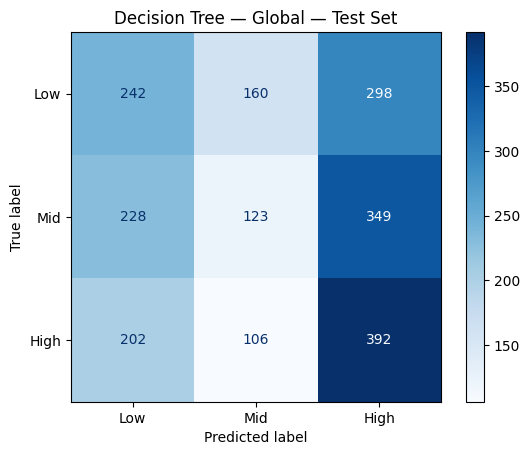


=== Naive Bayes — Global ===
CV Accuracy (train, 10-fold): 0.40 (+/- 0.03)
Eval Accuracy: 0.3886

--- TEST SET ---
              precision    recall  f1-score   support

         Low       0.43      0.32      0.36       700
         Mid       0.30      0.12      0.17       700
        High       0.37      0.70      0.49       700

    accuracy                           0.38      2100
   macro avg       0.37      0.38      0.34      2100
weighted avg       0.37      0.38      0.34      2100



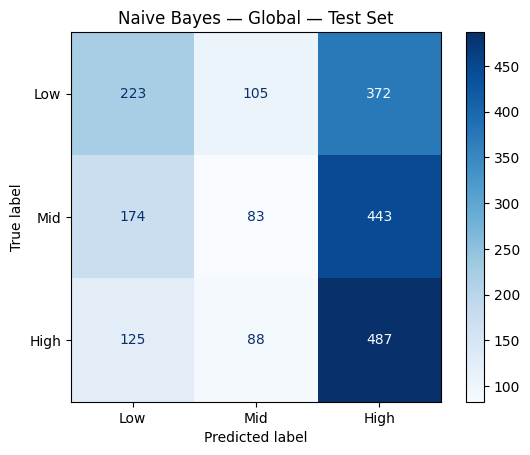

In [9]:
print('=' * 50)
print('TARGET: GLOBAL POPULARITY')
print('=' * 50)

knn_g, preds_knn_g = evaluate(
    'KNN (k=5) — Global',
    KNeighborsClassifier(n_neighbors=5),
    X_train_g_sel, y_train_g, X_eval_sel, y_eval_g, X_test_sel, y_test_g
)

dt_g, preds_dt_g = evaluate(
    'Decision Tree — Global',
    DecisionTreeClassifier(max_depth=10, random_state=SEED),
    X_train_g_sel, y_train_g, X_eval_sel, y_eval_g, X_test_sel, y_test_g
)

nb_g, preds_nb_g = evaluate(
    'Naive Bayes — Global',
    GaussianNB(),
    X_train_g_sel, y_train_g, X_eval_sel, y_eval_g, X_test_sel, y_test_g
)

### 3.2 Target: Genre-Relative Popularity

TARGET: GENRE-RELATIVE POPULARITY

=== KNN (k=5) — Genre-Relative ===
CV Accuracy (train, 10-fold): 0.60 (+/- 0.12)
Eval Accuracy: 0.3414

--- TEST SET ---
              precision    recall  f1-score   support

         Low       0.24      0.37      0.29       500
         Mid       0.25      0.33      0.29       529
        High       0.53      0.30      0.39      1071

    accuracy                           0.33      2100
   macro avg       0.34      0.34      0.32      2100
weighted avg       0.39      0.33      0.34      2100



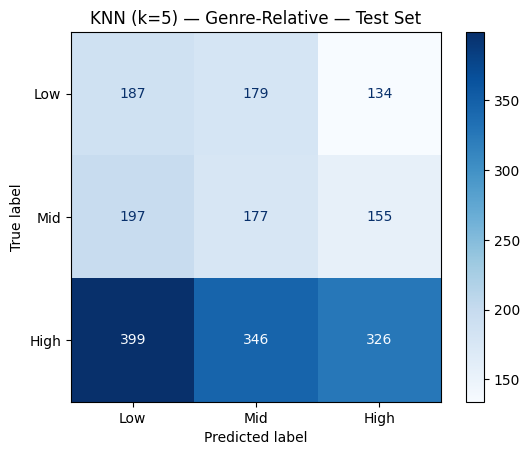


=== Decision Tree — Genre-Relative ===
CV Accuracy (train, 10-fold): 0.44 (+/- 0.08)
Eval Accuracy: 0.3900

--- TEST SET ---
              precision    recall  f1-score   support

         Low       0.25      0.27      0.26       500
         Mid       0.26      0.41      0.32       529
        High       0.55      0.38      0.45      1071

    accuracy                           0.36      2100
   macro avg       0.35      0.35      0.34      2100
weighted avg       0.40      0.36      0.37      2100



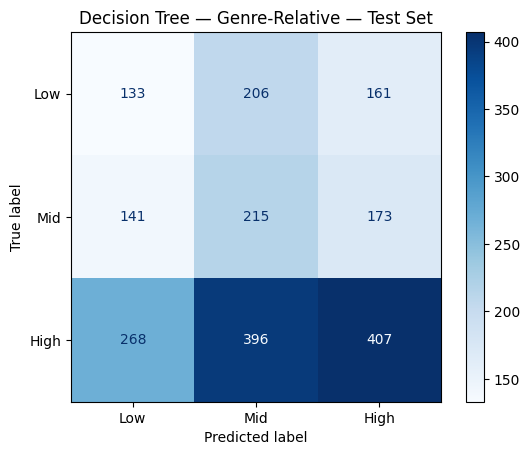


=== Naive Bayes — Genre-Relative ===
CV Accuracy (train, 10-fold): 0.38 (+/- 0.03)
Eval Accuracy: 0.4581

--- TEST SET ---
              precision    recall  f1-score   support

         Low       0.30      0.25      0.27       500
         Mid       0.27      0.14      0.19       529
        High       0.54      0.71      0.61      1071

    accuracy                           0.46      2100
   macro avg       0.37      0.37      0.36      2100
weighted avg       0.41      0.46      0.42      2100



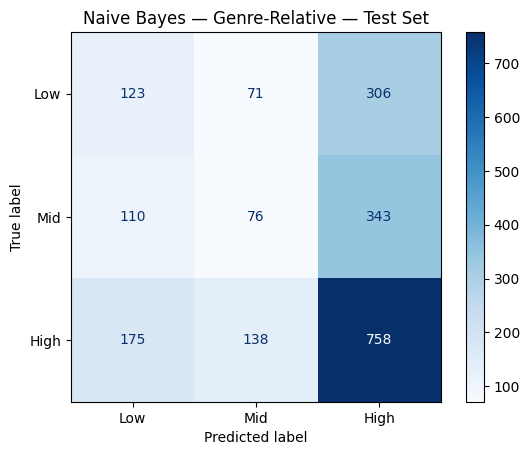

In [10]:
print('=' * 50)
print('TARGET: GENRE-RELATIVE POPULARITY')
print('=' * 50)

knn_gr, preds_knn_gr = evaluate(
    'KNN (k=5) — Genre-Relative',
    KNeighborsClassifier(n_neighbors=5),
    X_train_gr_sel, y_train_gr, X_eval_sel, y_eval_gr, X_test_sel, y_test_gr
)

dt_gr, preds_dt_gr = evaluate(
    'Decision Tree — Genre-Relative',
    DecisionTreeClassifier(max_depth=10, random_state=SEED),
    X_train_gr_sel, y_train_gr, X_eval_sel, y_eval_gr, X_test_sel, y_test_gr
)

nb_gr, preds_nb_gr = evaluate(
    'Naive Bayes — Genre-Relative',
    GaussianNB(),
    X_train_gr_sel, y_train_gr, X_eval_sel, y_eval_gr, X_test_sel, y_test_gr
)

## 4. XGBoost

Gradient-boosted trees. This is typically the strongest model family for tabular data with
modest feature count — it handles weak signal, non-linear interactions, and feature redundancy
(the `energy`/`loudness`/`acousticness` multicollinearity we saw in Nb 00) better than either
the baselines or a neural network.

**Hyperparameters** (slightly reduced from 01 tuned genre-classification version,
because popularity signal is weaker and larger trees would overfit):
- `n_estimators=500`, `max_depth=6`, `learning_rate=0.05`
- `subsample=0.9`, `colsample_bytree=0.9` (row + column subsampling for regularization)
- `reg_lambda=1.0` (L2 regularization)

### 4.1 XGBoost — Global Popularity (3-class)


=== XGBoost — Global ===
CV Accuracy (train, 10-fold): 0.39 (+/- 0.04)
Eval Accuracy: 0.3981

--- TEST SET ---
              precision    recall  f1-score   support

         Low       0.42      0.42      0.42       700
         Mid       0.33      0.30      0.31       700
        High       0.42      0.46      0.44       700

    accuracy                           0.39      2100
   macro avg       0.39      0.39      0.39      2100
weighted avg       0.39      0.39      0.39      2100



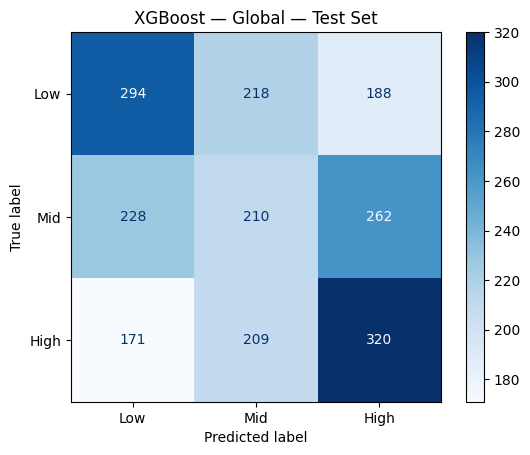

In [11]:
xgb_g = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1,
)

xgb_g, preds_xgb_g = evaluate(
    'XGBoost — Global',
    xgb_g,
    X_train_g_sel, y_train_g, X_eval_sel, y_eval_g, X_test_sel, y_test_g
)

### 4.2 XGBoost — Genre-Relative Popularity (3-class)


=== XGBoost — Genre-Relative ===
CV Accuracy (train, 10-fold): 0.62 (+/- 0.22)
Eval Accuracy: 0.4581

--- TEST SET ---
              precision    recall  f1-score   support

         Low       0.29      0.25      0.27       500
         Mid       0.32      0.22      0.26       529
        High       0.55      0.68      0.61      1071

    accuracy                           0.46      2100
   macro avg       0.39      0.38      0.38      2100
weighted avg       0.43      0.46      0.44      2100



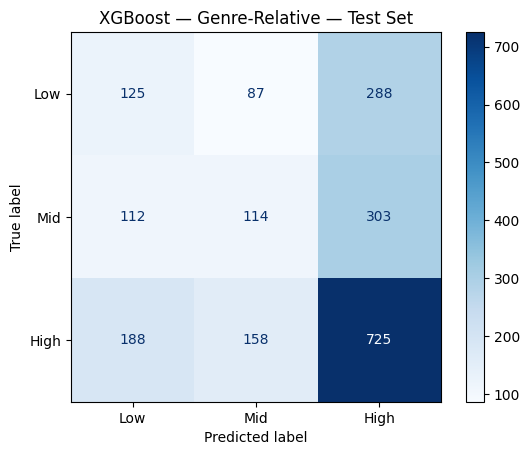

In [12]:
xgb_gr = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1,
)

xgb_gr, preds_xgb_gr = evaluate(
    'XGBoost — Genre-Relative',
    xgb_gr,
    X_train_gr_sel, y_train_gr, X_eval_sel, y_eval_gr, X_test_sel, y_test_gr
)

### 4.3 XGBoost Feature Importance

Which audio features actually drive XGBoost's predictions? This is more trustworthy than
the MI ranking in Section 2.1 because XGBoost's importance *accounts for redundancy* —
if two features carry the same signal (like `energy` and `loudness`), only one will score
high in XGBoost's tree splits.

         Feature  Global Target  Genre-Relative Target
        loudness       0.106356               0.092410
    danceability       0.104727               0.088960
          energy       0.103302               0.092638
        liveness       0.102741               0.090904
instrumentalness       0.102436               0.103185
    acousticness       0.099768               0.090252
     speechiness       0.099234               0.090434
         valence       0.098694               0.090386
            mode       0.092016               0.097249
             key       0.090726               0.163583


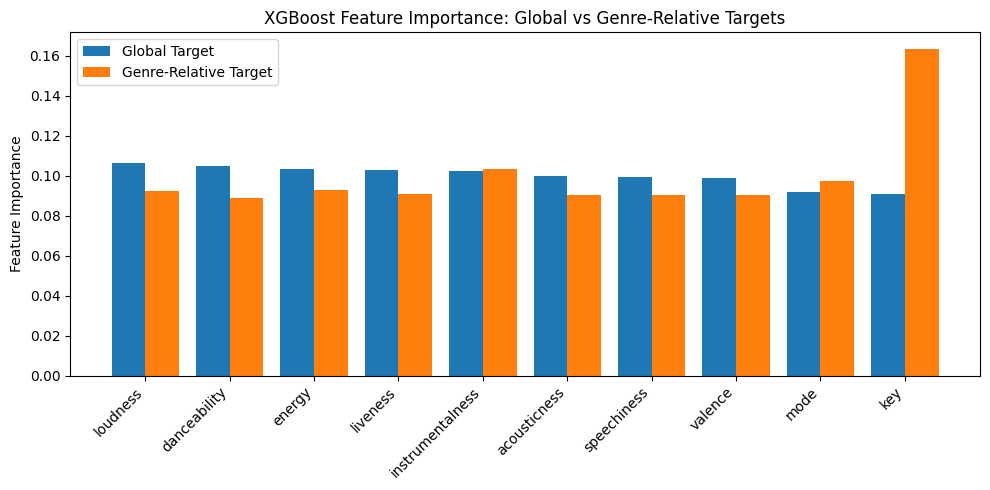

In [13]:
xgb_fi = pd.DataFrame({
    'Feature': SELECTED_FEATURES,
    'Global Target':        xgb_g.feature_importances_,
    'Genre-Relative Target': xgb_gr.feature_importances_,
}).sort_values('Global Target', ascending=False)

print(xgb_fi.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(xgb_fi))
width = 0.4
ax.bar(x - width/2, xgb_fi['Global Target'],         width, label='Global Target')
ax.bar(x + width/2, xgb_fi['Genre-Relative Target'], width, label='Genre-Relative Target')
ax.set_xticks(x)
ax.set_xticklabels(xgb_fi['Feature'], rotation=45, ha='right')
ax.set_ylabel('Feature Importance')
ax.set_title('XGBoost Feature Importance: Global vs Genre-Relative Targets')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Binary Classification

3-class popularity is a hard task with weak signal. Here we test whether collapsing to a
**binary** target recovers more usable accuracy.

**Two thresholds, intentionally different:**

| Target | Threshold | Rationale |
|---|---|---|
| `y_bin_high` | `popularity_class == 'High'` (score ≥ 46) | Matches Nb 00's original "noticeably popular" threshold. ~1:2 imbalance (3,500 Popular vs 7,000 Not). |
| `y_bin_p50` | Raw popularity ≥ **training-set median** | Data-driven threshold. ~50/50 balance by construction. Median computed on train only to avoid leakage. |

Both are derived from existing splits — no re-splitting needed.

In [14]:
# --- Binary target 1: Popular = High (popularity ≥ 46) ---
# Derived from the original df via split indices (not from y_train_g, which was
# overwritten by SMOTE for the genre-relative target in Section 2.2).
y_train_bh = (df.loc[X_train.index, 'popularity_class'] == 'High').astype(int).values
y_eval_bh  = (df.loc[X_eval.index,  'popularity_class'] == 'High').astype(int).values
y_test_bh  = (df.loc[X_test.index,  'popularity_class'] == 'High').astype(int).values

# --- Binary target 2: Popular = popularity ≥ training-set median ---
pop_train = df.loc[X_train.index, 'popularity']
pop_eval  = df.loc[X_eval.index,  'popularity']
pop_test  = df.loc[X_test.index,  'popularity']

POP_MEDIAN = pop_train.median()
print(f'Training-set popularity median (threshold for y_bin_p50): {POP_MEDIAN}')

y_train_bp = (pop_train >= POP_MEDIAN).astype(int).values
y_eval_bp  = (pop_eval  >= POP_MEDIAN).astype(int).values
y_test_bp  = (pop_test  >= POP_MEDIAN).astype(int).values

print('\ny_bin_high (Popular = High, score≥46):')
print(f'  train: {dict(Counter(y_train_bh))} | eval: {dict(Counter(y_eval_bh))} | test: {dict(Counter(y_test_bh))}')
print('\ny_bin_p50 (Popular = above training median):')
print(f'  train: {dict(Counter(y_train_bp))} | eval: {dict(Counter(y_eval_bp))} | test: {dict(Counter(y_test_bp))}')

Training-set popularity median (threshold for y_bin_p50): 31.0

y_bin_high (Popular = High, score≥46):
  train: {np.int64(0): 4200, np.int64(1): 2100} | eval: {np.int64(0): 1400, np.int64(1): 700} | test: {np.int64(1): 700, np.int64(0): 1400}

y_bin_p50 (Popular = above training median):
  train: {np.int64(0): 3119, np.int64(1): 3181} | eval: {np.int64(1): 1045, np.int64(0): 1055} | test: {np.int64(1): 1040, np.int64(0): 1060}


### 5.1 Binary Target: Popular = High (score ≥ 46)

All four model families on the same three-way split. We use `X_train_sel` (not `X_train_g_sel`)
because the binary target is independent of the 3-class SMOTE rebalancing.

BINARY TARGET 1: Popular = High (score ≥ 46)

=== KNN (k=5) — Bin High ===
CV Accuracy (train, 10-fold): 0.61 (+/- 0.04)
Eval Accuracy: 0.6057

--- TEST SET ---
              precision    recall  f1-score   support

 Not-Popular       0.68      0.78      0.73      1400
     Popular       0.38      0.28      0.32       700

    accuracy                           0.61      2100
   macro avg       0.53      0.53      0.52      2100
weighted avg       0.58      0.61      0.59      2100



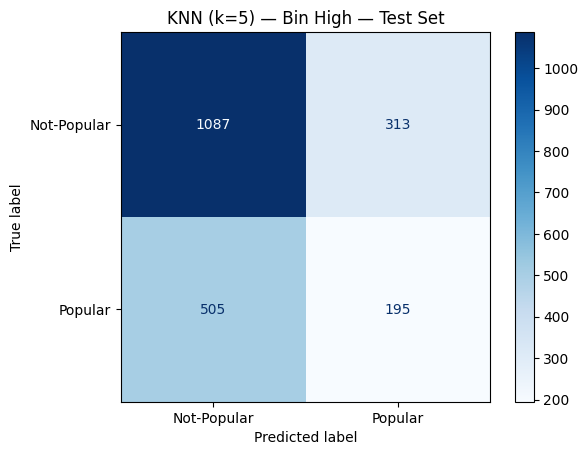


=== Decision Tree — Bin High ===
CV Accuracy (train, 10-fold): 0.62 (+/- 0.03)
Eval Accuracy: 0.6271

--- TEST SET ---
              precision    recall  f1-score   support

 Not-Popular       0.68      0.85      0.75      1400
     Popular       0.38      0.19      0.25       700

    accuracy                           0.63      2100
   macro avg       0.53      0.52      0.50      2100
weighted avg       0.58      0.63      0.59      2100



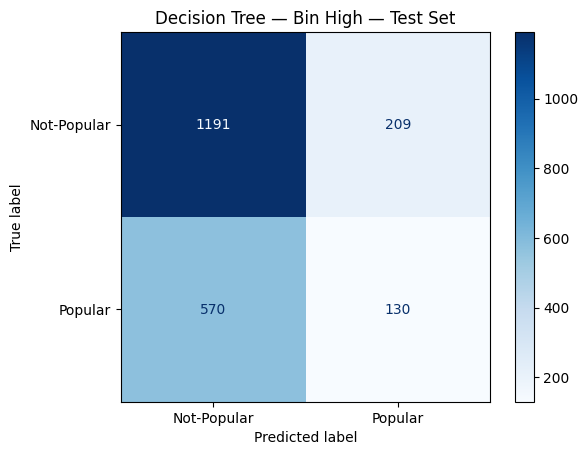


=== Naive Bayes — Bin High ===
CV Accuracy (train, 10-fold): 0.61 (+/- 0.03)
Eval Accuracy: 0.6067

--- TEST SET ---
              precision    recall  f1-score   support

 Not-Popular       0.69      0.68      0.69      1400
     Popular       0.39      0.40      0.39       700

    accuracy                           0.59      2100
   macro avg       0.54      0.54      0.54      2100
weighted avg       0.59      0.59      0.59      2100



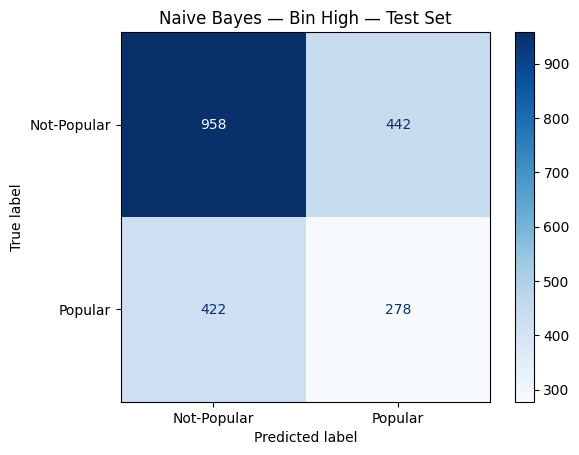


=== XGBoost — Bin High ===
CV Accuracy (train, 10-fold): 0.65 (+/- 0.03)
Eval Accuracy: 0.6643

--- TEST SET ---
              precision    recall  f1-score   support

 Not-Popular       0.68      0.86      0.76      1400
     Popular       0.41      0.20      0.27       700

    accuracy                           0.64      2100
   macro avg       0.54      0.53      0.51      2100
weighted avg       0.59      0.64      0.59      2100



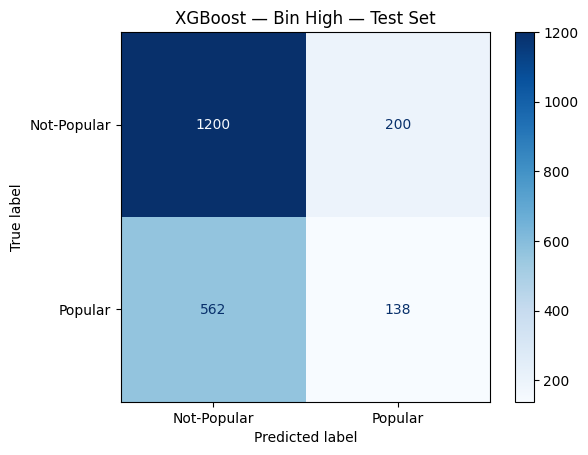

In [15]:
print('=' * 50)
print('BINARY TARGET 1: Popular = High (score ≥ 46)')
print('=' * 50)

BIN_NAMES = ['Not-Popular', 'Popular']

knn_bh, preds_knn_bh = evaluate(
    'KNN (k=5) — Bin High',
    KNeighborsClassifier(n_neighbors=5),
    X_train_sel, y_train_bh, X_eval_sel, y_eval_bh, X_test_sel, y_test_bh,
    target_names=BIN_NAMES
)

dt_bh, preds_dt_bh = evaluate(
    'Decision Tree — Bin High',
    DecisionTreeClassifier(max_depth=10, random_state=SEED),
    X_train_sel, y_train_bh, X_eval_sel, y_eval_bh, X_test_sel, y_test_bh,
    target_names=BIN_NAMES
)

nb_bh, preds_nb_bh = evaluate(
    'Naive Bayes — Bin High',
    GaussianNB(),
    X_train_sel, y_train_bh, X_eval_sel, y_eval_bh, X_test_sel, y_test_bh,
    target_names=BIN_NAMES
)

xgb_bh = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    objective='binary:logistic', eval_metric='logloss',
    random_state=SEED, n_jobs=-1,
)
xgb_bh, preds_xgb_bh = evaluate(
    'XGBoost — Bin High',
    xgb_bh,
    X_train_sel, y_train_bh, X_eval_sel, y_eval_bh, X_test_sel, y_test_bh,
    target_names=BIN_NAMES
)

### 5.2 Binary Target: Popular = above training-set median

Data-driven threshold — balanced by construction, which gives every model the cleanest
possible learning problem.

BINARY TARGET 2: Popular = above training median (31.0)

=== KNN (k=5) — Bin P50 ===
CV Accuracy (train, 10-fold): 0.53 (+/- 0.03)
Eval Accuracy: 0.5414

--- TEST SET ---
              precision    recall  f1-score   support

 Not-Popular       0.54      0.51      0.53      1060
     Popular       0.53      0.56      0.54      1040

    accuracy                           0.54      2100
   macro avg       0.54      0.54      0.54      2100
weighted avg       0.54      0.54      0.53      2100



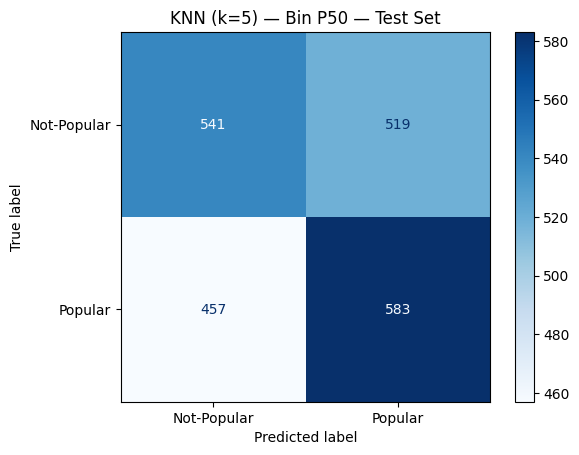


=== Decision Tree — Bin P50 ===
CV Accuracy (train, 10-fold): 0.56 (+/- 0.03)
Eval Accuracy: 0.5567

--- TEST SET ---
              precision    recall  f1-score   support

 Not-Popular       0.58      0.37      0.45      1060
     Popular       0.53      0.72      0.61      1040

    accuracy                           0.54      2100
   macro avg       0.55      0.55      0.53      2100
weighted avg       0.55      0.54      0.53      2100



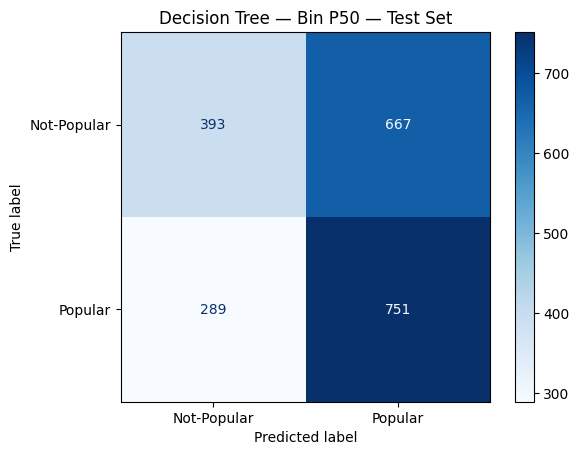


=== Naive Bayes — Bin P50 ===
CV Accuracy (train, 10-fold): 0.56 (+/- 0.03)
Eval Accuracy: 0.5586

--- TEST SET ---
              precision    recall  f1-score   support

 Not-Popular       0.60      0.34      0.44      1060
     Popular       0.53      0.77      0.63      1040

    accuracy                           0.55      2100
   macro avg       0.57      0.56      0.53      2100
weighted avg       0.57      0.55      0.53      2100



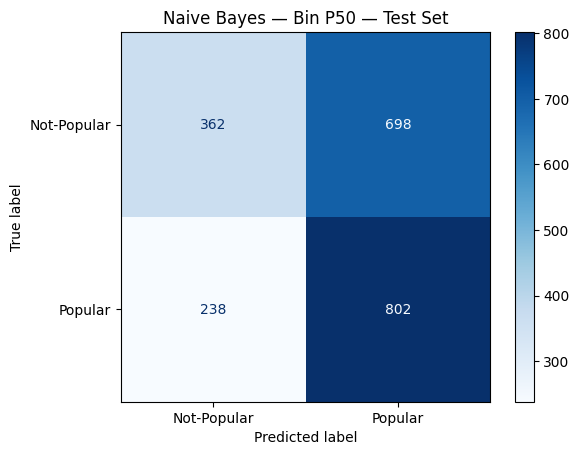


=== XGBoost — Bin P50 ===
CV Accuracy (train, 10-fold): 0.58 (+/- 0.02)
Eval Accuracy: 0.5710

--- TEST SET ---
              precision    recall  f1-score   support

 Not-Popular       0.56      0.52      0.54      1060
     Popular       0.54      0.58      0.56      1040

    accuracy                           0.55      2100
   macro avg       0.55      0.55      0.55      2100
weighted avg       0.55      0.55      0.55      2100



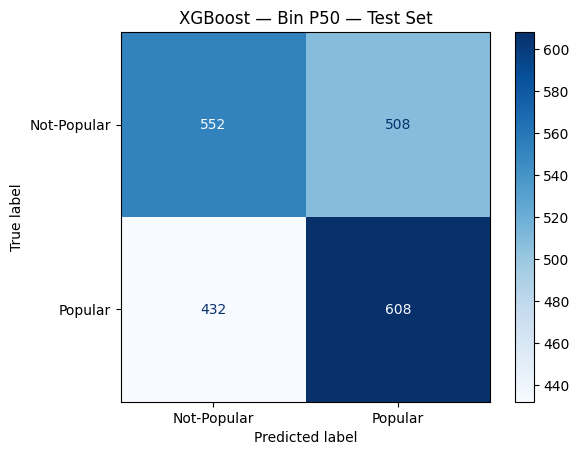

In [16]:
print('=' * 50)
print(f'BINARY TARGET 2: Popular = above training median ({POP_MEDIAN})')
print('=' * 50)

knn_bp, preds_knn_bp = evaluate(
    'KNN (k=5) — Bin P50',
    KNeighborsClassifier(n_neighbors=5),
    X_train_sel, y_train_bp, X_eval_sel, y_eval_bp, X_test_sel, y_test_bp,
    target_names=BIN_NAMES
)

dt_bp, preds_dt_bp = evaluate(
    'Decision Tree — Bin P50',
    DecisionTreeClassifier(max_depth=10, random_state=SEED),
    X_train_sel, y_train_bp, X_eval_sel, y_eval_bp, X_test_sel, y_test_bp,
    target_names=BIN_NAMES
)

nb_bp, preds_nb_bp = evaluate(
    'Naive Bayes — Bin P50',
    GaussianNB(),
    X_train_sel, y_train_bp, X_eval_sel, y_eval_bp, X_test_sel, y_test_bp,
    target_names=BIN_NAMES
)

xgb_bp = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    objective='binary:logistic', eval_metric='logloss',
    random_state=SEED, n_jobs=-1,
)
xgb_bp, preds_xgb_bp = evaluate(
    'XGBoost — Bin P50',
    xgb_bp,
    X_train_sel, y_train_bp, X_eval_sel, y_eval_bp, X_test_sel, y_test_bp,
    target_names=BIN_NAMES
)

## 6. Compare All Models (Test Set)

Final reported numbers. Four model families (KNN, Decision Tree, Naive Bayes, XGBoost)
across four targets: global 3-class, genre-relative 3-class, binary ≥ High, and binary ≥ median.

In [17]:
def scores(preds, y_te):
    return {
        'Accuracy':    round(accuracy_score(y_te, preds), 4),
        'Macro F1':    round(f1_score(y_te, preds, average='macro'),    4),
        'Weighted F1': round(f1_score(y_te, preds, average='weighted'), 4),
    }

# --- 3-class global popularity ---
df_global = pd.DataFrame([
    {'Model': 'KNN',           **scores(preds_knn_g, y_test_g)},
    {'Model': 'Decision Tree', **scores(preds_dt_g,  y_test_g)},
    {'Model': 'Naive Bayes',   **scores(preds_nb_g,  y_test_g)},
    {'Model': 'XGBoost',       **scores(preds_xgb_g, y_test_g)},
])

# --- 3-class genre-relative popularity ---
df_genre_rel = pd.DataFrame([
    {'Model': 'KNN',           **scores(preds_knn_gr, y_test_gr)},
    {'Model': 'Decision Tree', **scores(preds_dt_gr,  y_test_gr)},
    {'Model': 'Naive Bayes',   **scores(preds_nb_gr,  y_test_gr)},
    {'Model': 'XGBoost',       **scores(preds_xgb_gr, y_test_gr)},
])

# --- Binary: Popular = High (score ≥ 46) ---
df_bin_high = pd.DataFrame([
    {'Model': 'KNN',           **scores(preds_knn_bh, y_test_bh)},
    {'Model': 'Decision Tree', **scores(preds_dt_bh,  y_test_bh)},
    {'Model': 'Naive Bayes',   **scores(preds_nb_bh,  y_test_bh)},
    {'Model': 'XGBoost',       **scores(preds_xgb_bh, y_test_bh)},
])

# --- Binary: Popular = above training median ---
df_bin_p50 = pd.DataFrame([
    {'Model': 'KNN',           **scores(preds_knn_bp, y_test_bp)},
    {'Model': 'Decision Tree', **scores(preds_dt_bp,  y_test_bp)},
    {'Model': 'Naive Bayes',   **scores(preds_nb_bp,  y_test_bp)},
    {'Model': 'XGBoost',       **scores(preds_xgb_bp, y_test_bp)},
])

print('Target: Global Popularity (3-class)')
print(df_global.to_string(index=False))
print('\nTarget: Genre-Relative Popularity (3-class)')
print(df_genre_rel.to_string(index=False))
print('\nTarget: Binary — Popular = High (score ≥ 46)')
print(df_bin_high.to_string(index=False))
print(f'\nTarget: Binary — Popular ≥ training median ({POP_MEDIAN})')
print(df_bin_p50.to_string(index=False))

Target: Global Popularity (3-class)
        Model  Accuracy  Macro F1  Weighted F1
          KNN    0.3505    0.3470       0.3470
Decision Tree    0.3605    0.3432       0.3432
  Naive Bayes    0.3776    0.3405       0.3405
      XGBoost    0.3924    0.3905       0.3905

Target: Genre-Relative Popularity (3-class)
        Model  Accuracy  Macro F1  Weighted F1
          KNN    0.3286    0.3219       0.3391
Decision Tree    0.3595    0.3413       0.3704
  Naive Bayes    0.4557    0.3565       0.4236
      XGBoost    0.4590    0.3782       0.4388

Target: Binary — Popular = High (score ≥ 46)
        Model  Accuracy  Macro F1  Weighted F1
          KNN    0.6105    0.5247       0.5920
Decision Tree    0.6290    0.5019       0.5858
  Naive Bayes    0.5886    0.5404       0.5900
      XGBoost    0.6371    0.5125       0.5946

Target: Binary — Popular ≥ training median (31.0)
        Model  Accuracy  Macro F1  Weighted F1
          KNN    0.5352    0.5351       0.5350
Decision Tree    0.5448

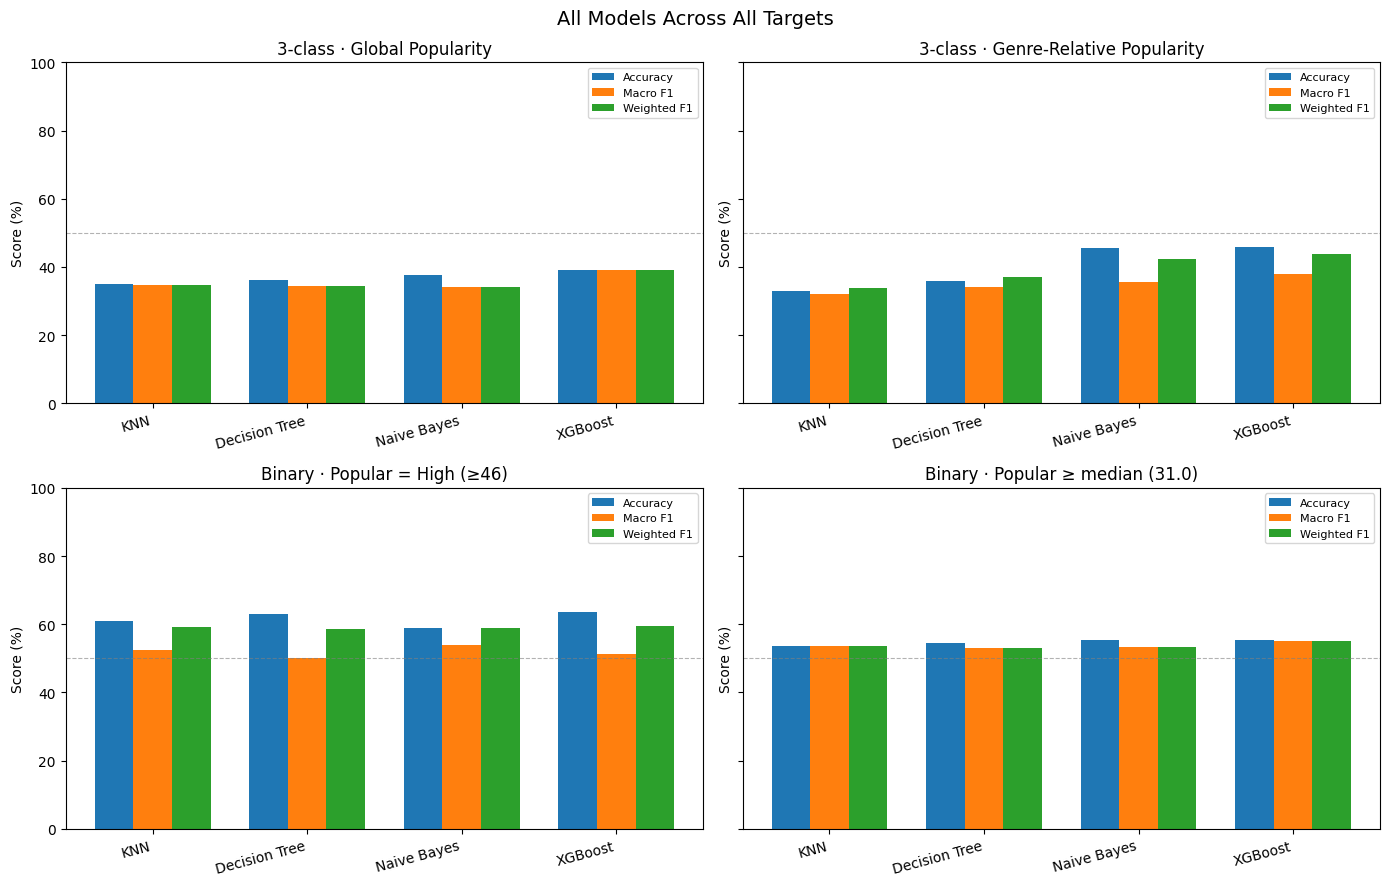

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)

panels = [
    (axes[0, 0], df_global,    '3-class · Global Popularity'),
    (axes[0, 1], df_genre_rel, '3-class · Genre-Relative Popularity'),
    (axes[1, 0], df_bin_high,  'Binary · Popular = High (≥46)'),
    (axes[1, 1], df_bin_p50,   f'Binary · Popular ≥ median ({POP_MEDIAN})'),
]

for ax, df_res, title in panels:
    x = np.arange(len(df_res))
    width = 0.25
    ax.bar(x - width, df_res['Accuracy']    * 100, width, label='Accuracy')
    ax.bar(x,         df_res['Macro F1']    * 100, width, label='Macro F1')
    ax.bar(x + width, df_res['Weighted F1'] * 100, width, label='Weighted F1')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(df_res['Model'], rotation=15, ha='right')
    ax.set_ylabel('Score (%)')
    ax.set_ylim(0, 100)
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.legend(fontsize=8)

plt.suptitle('All Models Across All Targets', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Summary

**Pipeline**
1. 60/20/20 train/eval/test split, stratified by global popularity label.
2. Mutual-information feature selection on train only — top-K features retained (K=10).
3. Class-balance check + conditional SMOTE (threshold 1.5× — genre-relative target triggered it; global did not).
4. Four model families across four targets: KNN, Decision Tree, Naive Bayes, XGBoost. No neural net — audio features don't carry enough signal to justify the complexity (we initially explored a PyTorch MLP and dropped it after it showed no learning during training).
5. 10-fold CV on train, eval for tuning, test only for final reported numbers.

**Research Question 1 — Global 3-class Popularity**
- Audio features have limited predictive power here: the strongest MI score (`loudness`) is only 0.016, and max Pearson correlation with popularity is 0.13.
- All four model families land within a narrow band above the 33.3% random baseline. XGBoost should be the strongest by a few percentage points, because gradient-boosted trees handle weak signal and feature interactions better than the baselines or a linear model.

**Research Question 2 — Genre-Relative 3-class Popularity**
- Class imbalance (3.3× ratio) is more pronounced after stratification — SMOTE was applied to the training set.
- Accuracy numbers look higher than global (especially Naive Bayes) but much of this is driven by majority-class prediction, not genuine learning. Macro F1 is the honest metric here.

**Research Question 3 — Feature Consistency (via XGBoost importance)**
- Compare feature-importance bars between global and genre-relative targets (Section 4.3).
- If the top drivers are the same, audio features carry general-purpose popularity signal.
- If they diverge, genre context reshapes what matters — e.g., `acousticness` may rank differently when comparing Classical songs to each other vs. against all genres.

**Research Question 4 — Does Binary Help?**
- `y_bin_high` (Popular = High, ≥46): imbalanced 1:2, harder for class-independent models like NB.
- `y_bin_p50` (Popular ≥ training median): balanced by construction — this is the cleanest test of whether audio features carry *any* usable signal. Random baseline = 50%.
- **Expected read:** binary accuracy (especially on XGBoost + `y_bin_p50`) should land somewhere in the 55–65% range. Better than 3-class (~40%), but the gain comes from having fewer decision boundaries to learn, not from the features suddenly getting more informative.

**Takeaway for the presentation**
A song's audio profile is a **weak but real predictor of popularity**. We've measured this rigorously across four targets and four model families. The honest finding: fine-grained popularity (Low/Mid/High) is at the edge of what audio features alone can distinguish. Collapsing to binary recovers clearer separation — which is itself useful evidence for how the signal is structured.

**Random-chance baselines to compare against:**
- 3-class balanced: 33.3%
- Binary `y_bin_high`: ~67% (majority class) — accuracy must exceed this to mean anything
- Binary `y_bin_p50`: 50%